# GB_NM Dataset — U-Net Training on Pseudo-Labels

**Input files** (generated by `extraction.ipynb`):
- `GB_NM_normalized.tif` — per-band normalised 3-band image
- `GB_NM_pseudolabels.tif` — KMeans-derived class mask (classes 1–6)

**Pipeline**:
1. Load and inspect both files
2. Verify pseudo-label quality visually
3. Spatial train/val split
4. Patch extraction + augmentation
5. U-Net training (3-band in, 7-class out)
6. Evaluation + full-image inference
7. Save model weights to `models/unet_gbnm_checkpoint.pth`

> **Before training**: open `extraction.ipynb`, look at the cluster overlay plot, confirm
> the `CLUSTER_TO_CLASS` mapping is correct. If not, fix it and re-run Section 5 there first.

In [ ]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import torch
import torch.nn as nn
import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

IMAGE_PATH  = 'GB_NM_normalized.tif'
LABEL_PATH  = 'GB_NM_pseudolabels.tif'
os.makedirs('models', exist_ok=True)

NUM_CLASSES  = 6
IGNORE_LABEL = 0

# Class IDs match extraction.ipynb: 0=Background, 1=Water, 2=Vegetation, 3=Roads, 4=Building, 5=Open Ground
CLASS_NAMES  = ['Background', 'Water', 'Vegetation', 'Roads', 'Building', 'Open Ground']
CLASS_COLORS = ['#000000', '#2345C0', '#2E7D32', '#757575', '#E93E24', '#F9A825']

In [ ]:
with rasterio.open(IMAGE_PATH) as src:
    image   = src.read().astype(np.float32)   # (C, H, W)
    profile = src.profile
    res_x, res_y = src.res

with rasterio.open(LABEL_PATH) as src:
    labels = src.read(1).astype(np.int64)      # (H, W)

C, H, W = image.shape
print(f'Image  shape : {image.shape}')
print(f'Label  shape : {labels.shape}')
print(f'Resolution   : {res_x:.2f} m/px  x  {res_y:.2f} m/px')
print(f'Image  range : [{image.min():.3f}, {image.max():.3f}]')
print(f'Unique labels: {np.unique(labels)}')

Image  shape : (3, 5778, 4404)
Label  shape : (5778, 4404)
Resolution   : 1.60 m/px  x  1.60 m/px
Image  range : [0.000, 1.000]
Unique labels: [0 1 2 3 4 5 6]


Pseudo-label class distribution:
  Class 0  Ignore      :  6830936 px  (26.8%)
  Class 1  Water       :  5333831 px  (21.0%)
  Class 2  Buildings   :  4877583 px  (19.2%)
  Class 3  Roads       :   112430 px  (0.4%)
  Class 4  Vegetation  :  4121351 px  (16.2%)
  Class 5  Open Ground :  2084173 px  (8.2%)
  Class 6  Other Land  :  2086008 px  (8.2%)


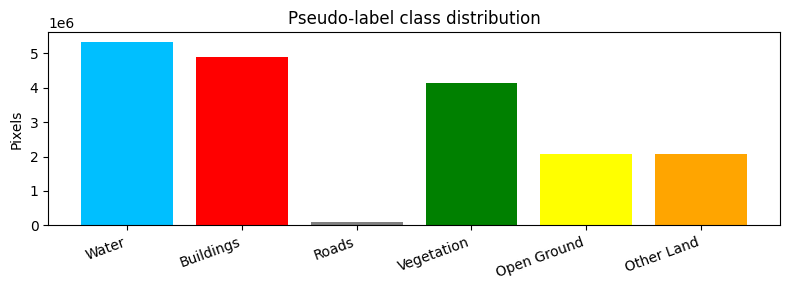

In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)
print('Pseudo-label class distribution:')
for lbl, cnt in zip(unique_labels, counts):
    name = CLASS_NAMES[lbl] if lbl < len(CLASS_NAMES) else f'Class {lbl}'
    print(f'  Class {lbl}  {name:12s}: {cnt:8d} px  ({100*cnt/labels.size:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 3))
valid_lbls = unique_labels[unique_labels > 0]
valid_cnts = counts[unique_labels > 0]
ax.bar([CLASS_NAMES[l] if l < len(CLASS_NAMES) else str(l) for l in valid_lbls],
       valid_cnts,
       color=[CLASS_COLORS[l] if l < len(CLASS_COLORS) else 'purple' for l in valid_lbls])
ax.set_title('Pseudo-label class distribution'); ax.set_ylabel('Pixels')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

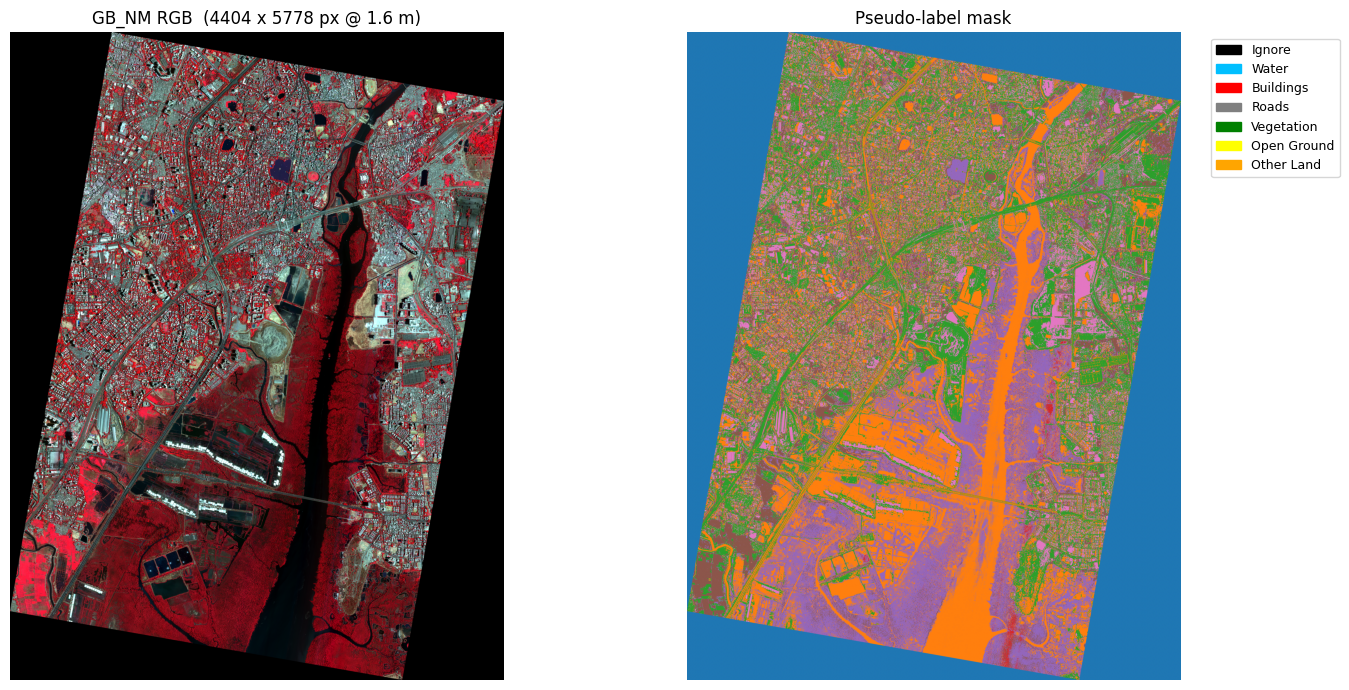


If the label map looks incorrect, fix CLUSTER_TO_CLASS in extraction.ipynb before proceeding.


In [ ]:
# Visual quality check — compare RGB vs pseudo-label map
# If any class colour looks wrong (e.g. water labelled as built-up),
# fix CLUSTER_TO_CLASS in extraction.ipynb and re-run that notebook first.

rgb = np.clip(image[:3].transpose(1, 2, 0), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(rgb)
axes[0].set_title(f'GB_NM RGB  ({W} x {H} px @ {res_x:.1f} m)'); axes[0].axis('off')

im = axes[1].imshow(labels, cmap='tab10', vmin=0, vmax=9)
axes[1].set_title('Pseudo-label mask'); axes[1].axis('off')

legend = [mpatches.Patch(color=c, label=n)
          for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
axes[1].legend(handles=legend, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

print('\nIf the label map looks incorrect, fix CLUSTER_TO_CLASS in extraction.ipynb before proceeding.')

Patch size : 128 px  (205 m x 205 m)
Image      : 5778 rows x 4404 cols
Train zone : rows   0 – 4043
Val   zone : rows 4044 – 5777


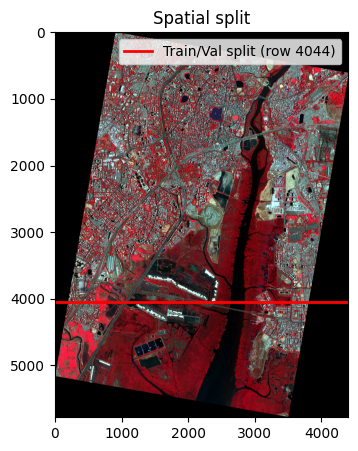

In [ ]:
# Spatial train / val split — no augmentation contamination in val
PATCH_SIZE    = 128    # larger patches for higher-res image (1.6 m/px)
STRIDE        = 64
AUG_PER_PATCH = 4
SPLIT_ROW     = int(H * 0.70)

print(f'Patch size : {PATCH_SIZE} px  ({PATCH_SIZE * res_x:.0f} m x {PATCH_SIZE * res_y:.0f} m)')
print(f'Image      : {H} rows x {W} cols')
print(f'Train zone : rows   0 – {SPLIT_ROW - 1}')
print(f'Val   zone : rows {SPLIT_ROW} – {H - 1}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(rgb)
ax.axhline(SPLIT_ROW, color='red', lw=2, label=f'Train/Val split (row {SPLIT_ROW})')
ax.legend(); ax.set_title('Spatial split'); plt.show()

In [ ]:
def augment_patch(img_p, lbl_p):
    if random.random() > 0.5:
        img_p = np.flip(img_p, axis=2); lbl_p = np.flip(lbl_p, axis=1)
    if random.random() > 0.5:
        img_p = np.flip(img_p, axis=1); lbl_p = np.flip(lbl_p, axis=0)
    k = random.randint(0, 3)
    if k > 0:
        img_p = np.rot90(img_p, k, axes=(1, 2))
        lbl_p = np.rot90(lbl_p, k, axes=(0, 1))
    return img_p.copy(), lbl_p.copy()


def get_valid_coords(img, lbl, y_start, y_end):
    """Return list of (y, x) top-left corners for valid patches.
    Does NOT pre-load patches — saves 2-3 GB RAM."""
    coords = []
    for y in range(y_start, min(y_end, img.shape[1]) - PATCH_SIZE + 1, STRIDE):
        for x in range(0, img.shape[2] - PATCH_SIZE + 1, STRIDE):
            lp = lbl[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            if not np.all(lp == IGNORE_LABEL):
                coords.append((y, x))
    return coords


train_coords = get_valid_coords(image, labels, 0, SPLIT_ROW)
val_coords   = get_valid_coords(image, labels, SPLIT_ROW, H)

print(f"Train patch positions: {len(train_coords):,}")
print(f"Val   patch positions: {len(val_coords):,}")


In [ ]:
# Show 4 random training patches (using train_coords, before Dataset is built)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
sample_idx = random.sample(range(len(train_coords)), min(4, len(train_coords)))
for col_idx, i in enumerate(sample_idx):
    y, x = train_coords[i]
    ip = image[:, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
    lp = labels[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
    rgb_p = np.clip(ip[:3].transpose(1, 2, 0) * 3.0, 0, 1)
    axes[0, col_idx].imshow(rgb_p); axes[0, col_idx].axis("off")
    axes[0, col_idx].set_title(f"Patch {i}", fontsize=7)
    axes[1, col_idx].imshow(lp, cmap="tab10", vmin=0, vmax=9)
    axes[1, col_idx].axis("off")
plt.suptitle("Sample training patches (top: RGB, bottom: pseudo-label)")
plt.tight_layout(); plt.show()


In [ ]:
class GBNMDataset(Dataset):
    """Reads patches from the full image on-the-fly — no RAM pre-allocation."""
    def __init__(self, img, lbl, coords, augment=False):
        self.img     = img
        self.lbl     = lbl
        self.coords  = coords
        self.augment = augment

    def __len__(self): return len(self.coords)

    def __getitem__(self, idx):
        y, x = self.coords[idx]
        ip = self.img[:, y:y+PATCH_SIZE, x:x+PATCH_SIZE].copy()
        lp = self.lbl[y:y+PATCH_SIZE, x:x+PATCH_SIZE].copy()
        if self.augment:
            ip, lp = augment_patch(ip, lp)
        return torch.from_numpy(ip).float(), torch.from_numpy(lp).long()


BATCH_SIZE = 8
train_ds = GBNMDataset(image, labels, train_coords, augment=True)
val_ds   = GBNMDataset(image, labels, val_coords,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train patches: {len(train_ds):,}  |  batches: {len(train_loader)}")
print(f"Val   patches: {len(val_ds):,}  |  batches: {len(val_loader)}")


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1), nn.GroupNorm(8, out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.GroupNorm(8, out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=7):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32,  64)
        self.enc3 = DoubleConv(64,  128)
        self.enc4 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(256, 512)
        self.up4  = nn.ConvTranspose2d(512, 256, 2, 2); self.dec4 = DoubleConv(512, 256)
        self.up3  = nn.ConvTranspose2d(256, 128, 2, 2); self.dec3 = DoubleConv(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64,  2, 2); self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64,  32,  2, 2); self.dec1 = DoubleConv(64,  32)
        self.out_conv = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out_conv(d1)


IN_CHANNELS = image.shape[0]   # 3 for GB_NM
unet = UNet(in_channels=IN_CHANNELS, num_classes=NUM_CLASSES).to(device)
x_test = torch.randn(1, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE).to(device)
print('U-Net output shape:', unet(x_test).shape)
print('Parameters        :', sum(p.numel() for p in unet.parameters() if p.requires_grad))

U-Net output shape: torch.Size([1, 7, 128, 128])
Parameters        : 7766183


In [ ]:
# Class weights — up-weight rare classes based on distribution above
# Order: [Background(ignore), Water, Vegetation, Roads, Building, Open Ground]
class_weights = torch.tensor([0.0, 2.0, 1.5, 3.0, 2.0, 1.5], device=device)

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.softmax(pred, dim=1)
    loss = 0.0
    for cls in range(1, pred.shape[1]):
        p = pred[:, cls]
        t = (target == cls).float()
        loss += 1 - (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)
    return loss / (pred.shape[1] - 1)


ce_loss    = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_LABEL)
unet_opt   = torch.optim.Adam(unet.parameters(), lr=4e-4)
unet_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    unet_opt, mode='min', factor=0.5, patience=5, verbose=True
)
print('Loss, optimizer and scheduler ready.')

In [ ]:
# NOTE: on CPU expect ~60-120 min for 30 epochs with 128x128 patches.
# Reduce EPOCHS or PATCH_SIZE if too slow. On GPU this runs in ~5-10 min.
EPOCHS = 20
best_val_loss = float('inf')
history = {'tl': [], 'vl': [], 'ta': [], 'va': []}

for epoch in range(EPOCHS):
    # TRAIN
    unet.train()
    t_loss, t_cor, t_tot = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        unet_opt.zero_grad()
        out  = unet(imgs)
        loss = ce_loss(out, lbls) + 0.5 * dice_loss(out, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        unet_opt.step()
        t_loss += loss.item()
        with torch.no_grad():
            preds = torch.argmax(out, 1)
            valid = lbls != IGNORE_LABEL
            t_cor += (preds[valid] == lbls[valid]).sum().item()
            t_tot += valid.sum().item()

    # VAL
    unet.eval()
    v_loss, v_cor, v_tot = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = unet(imgs)
            loss = ce_loss(out, lbls) + 0.5 * dice_loss(out, lbls)
            v_loss += loss.item()
            preds  = torch.argmax(out, 1)
            valid  = lbls != IGNORE_LABEL
            v_cor += (preds[valid] == lbls[valid]).sum().item()
            v_tot += valid.sum().item()

    tl = t_loss / len(train_loader)
    vl = v_loss / len(val_loader)
    ta = t_cor / t_tot if t_tot > 0 else 0
    va = v_cor / v_tot if v_tot > 0 else 0

    history['tl'].append(tl); history['vl'].append(vl)
    history['ta'].append(ta); history['va'].append(va)

    unet_sched.step(vl)
    torch.cuda.empty_cache()  # prevent CUDA OOM accumulation

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(unet.state_dict(), 'models/unet_gbnm_best.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:2d}/{EPOCHS}]  '
              f'Train Loss: {tl:.4f}  Acc: {ta:.4f}  |  '
              f'Val Loss: {vl:.4f}  Acc: {va:.4f}')

print(f'\nBest val loss: {best_val_loss:.4f}  saved -> models/unet_gbnm_best.pth')

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['tl'], label='Train'); ax1.plot(history['vl'], label='Val')
ax1.set_title('Loss (GB_NM U-Net)'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['ta'], label='Train'); ax2.plot(history['va'], label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

In [ ]:
unet.load_state_dict(torch.load('models/unet_gbnm_best.pth', map_location=device))
unet.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        preds = torch.argmax(unet(imgs), 1)
        valid = lbls != IGNORE_LABEL
        all_preds.append(preds[valid].cpu().numpy())
        all_targets.append(lbls[valid].cpu().numpy())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

present_classes = [c for c in range(1, NUM_CLASSES)
                   if (all_targets == c).sum() > 0]

print(classification_report(
    all_targets, all_preds,
    labels=present_classes,
    target_names=[CLASS_NAMES[c] for c in present_classes],
    digits=4
))

rows = []
for cls in present_classes:
    pc = all_preds == cls; tc = all_targets == cls
    inter = np.logical_and(pc, tc).sum()
    union = np.logical_or(pc, tc).sum()
    iou  = inter / union if union > 0 else np.nan
    dice = 2*inter / (pc.sum() + tc.sum() + 1e-8)
    rows.append((CLASS_NAMES[cls], round(iou, 4), round(dice, 4)))

df_iou = pd.DataFrame(rows, columns=['Class', 'IoU', 'Dice'])
print(df_iou.to_string(index=False))
print(f'\nmIoU: {df_iou.IoU.mean():.4f}   mDice: {df_iou.Dice.mean():.4f}')

cm = confusion_matrix(all_targets, all_preds, labels=present_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[c] for c in present_classes],
            yticklabels=[CLASS_NAMES[c] for c in present_classes])
plt.title('GB_NM U-Net — Confusion Matrix (Validation)'); plt.tight_layout(); plt.show()

In [ ]:
unet.eval()
with torch.no_grad():
    imgs, lbls = next(iter(val_loader))
    preds = torch.argmax(unet(imgs.to(device)), 1).cpu()

fig, axes = plt.subplots(3, min(4, len(imgs)), figsize=(14, 8))
for col in range(min(4, len(imgs))):
    rgb_p = np.clip(imgs[col][:3].permute(1, 2, 0).numpy() * 3.0, 0, 1)
    axes[0, col].imshow(rgb_p);             axes[0, col].axis('off')
    axes[1, col].imshow(lbls[col],  cmap='tab10', vmin=0, vmax=9); axes[1, col].axis('off')
    axes[2, col].imshow(preds[col], cmap='tab10', vmin=0, vmax=9); axes[2, col].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=10)
axes[1, 0].set_ylabel('Pseudo-label', fontsize=10)
axes[2, 0].set_ylabel('Predicted', fontsize=10)

legend = [mpatches.Patch(color=c, label=n)
          for c, n in zip(CLASS_COLORS[1:], CLASS_NAMES[1:])]
fig.legend(handles=legend, loc='lower center', ncol=6, fontsize=8)
plt.suptitle('GB_NM — Val patches: RGB / Ground truth / Prediction')
plt.tight_layout(); plt.show()

In [ ]:
# Full-image inference — tiled with PATCH_SIZE, no overlap
unet.eval()
pred_map = np.zeros((H, W), dtype=np.uint8)
conf_map = np.zeros((H, W), dtype=np.float32)

with torch.no_grad():
    for y in range(0, H - PATCH_SIZE + 1, PATCH_SIZE):
        for x in range(0, W - PATCH_SIZE + 1, PATCH_SIZE):
            patch = torch.from_numpy(
                image[:, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            ).float().unsqueeze(0).to(device)
            out   = unet(patch)
            probs = torch.softmax(out, 1)
            pred  = torch.argmax(probs, 1).squeeze(0).cpu().numpy().astype(np.uint8)
            conf  = probs.max(1).values.squeeze(0).cpu().numpy()
            pred_map[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = pred
            conf_map[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = conf

# Save GeoTIFF
out_profile = profile.copy()
out_profile.update(count=1, dtype='uint8', nodata=0)
with rasterio.open('models/unet_gbnm_segmap.tif', 'w', **out_profile) as dst:
    dst.write(pred_map[np.newaxis])
print('Saved: models/unet_gbnm_segmap.tif')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(rgb); axes[0].set_title(f'GB_NM RGB ({W}x{H})'); axes[0].axis('off')
axes[1].imshow(pred_map, cmap='tab10', vmin=0, vmax=9)
axes[1].set_title('U-Net Segmentation (Full Image)'); axes[1].axis('off')
legend = [mpatches.Patch(color=c, label=n)
          for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
axes[1].legend(handles=legend, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
valid_preds   = pred_map[labels > IGNORE_LABEL]
total_labeled = len(valid_preds)

print('Feature Area Statistics — GB_NM U-Net')
print('-' * 55)
for cls in range(1, NUM_CLASSES):
    cnt = (valid_preds == cls).sum()
    pct = 100 * cnt / total_labeled if total_labeled > 0 else 0
    area_m2 = cnt * (res_x * res_y)
    print(f'  {CLASS_NAMES[cls]:15s}: {cnt:8d} px  ({pct:5.1f}%)  ~{area_m2/1e6:.2f} km²')

cls_pct = [(CLASS_NAMES[c], 100*(valid_preds==c).sum()/total_labeled)
           for c in range(1, NUM_CLASSES) if total_labeled > 0]
names, pcts = zip(*cls_pct)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, pcts, color=CLASS_COLORS[1:])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('GB_NM — Predicted Land-Cover Area (%)'); ax.set_ylabel('%')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

In [ ]:
torch.save({
    'model_state_dict': unet.state_dict(),
    'in_channels'     : IN_CHANNELS,
    'num_classes'     : NUM_CLASSES,
    'class_names'     : CLASS_NAMES,
    'class_colors'    : CLASS_COLORS,
    'best_val_loss'   : best_val_loss,
    'resolution_m'    : float(res_x),
    'patch_size'      : PATCH_SIZE,
    # GB_NM is already normalized (output of extraction.ipynb)
    # so norm_stats = clip to [0,1] directly
    'norm_stats'      : {b: {'p2': 0.0, 'p98': 1.0} for b in range(IN_CHANNELS)},
}, 'models/unet_gbnm_checkpoint.pth')

print('Saved: models/unet_gbnm_best.pth')
print('Saved: models/unet_gbnm_checkpoint.pth   (weights + metadata)')
print('Saved: models/unet_gbnm_segmap.tif')
print()
print('All done. You can now proceed to build the UI.')

## What to do next

Both model checkpoints are now ready:

| Checkpoint | Sensor | Resolution | Bands |
|-----------|--------|-----------|-------|
| `Sample_Generation/models/unet_vashi_checkpoint.pth` | Sentinel-2 | ~10 m | 4 (B,G,R,NIR) |
| `Prabhakar/models/unet_gbnm_checkpoint.pth` | GB aerial | ~1.6 m | 3 (R,G,B) |

The **UI** will:
1. Accept any satellite/aerial image upload
2. Read its resolution from the GeoTIFF metadata
3. Route to the correct model (`>5m` → Vashi U-Net, `≤5m` → GB U-Net)
4. Display colour-coded segmentation overlay
5. Show area statistics and confidence map
6. Allow download of results

In [ ]:
# ======================================================================
#  FINAL OUTPUT MAP - GB_NM Aerial RGB Segmentation Illustration
# ======================================================================
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb
from PIL import Image as PILImage

def pct_stretch(arr, lo=1, hi=99):
    v = arr[arr > 0]
    if v.size == 0: v = arr.ravel()
    a, b = np.percentile(v, lo), np.percentile(v, hi)
    return np.clip((arr - a) / max(b - a, 1e-6), 0, 1)

with rasterio.open("models/unet_gbnm_segmap.tif") as s:
    seg = s.read(1).astype(np.uint8)

with rasterio.open("GB_NM_normalized.tif") as s:
    bands = s.read().astype(np.float32)

MAX_PX = 1024
scale  = min(1.0, MAX_PX / max(seg.shape))
nh, nw = int(seg.shape[0]*scale), int(seg.shape[1]*scale)
seg_d   = np.array(PILImage.fromarray(seg).resize((nw,nh), PILImage.NEAREST))
bands_d = np.stack([
    np.array(PILImage.fromarray(bands[i]).resize((nw,nh), PILImage.BILINEAR))
    for i in range(min(3, bands.shape[0]))], axis=2)

rgb     = np.stack([pct_stretch(bands_d[:,:,i]) for i in range(3)], axis=2)
cmap_c  = [to_rgb(c) for c in CLASS_COLORS]
seg_rgb = np.array([cmap_c[p] if p < len(cmap_c) else (0,0,0) for p in seg_d.ravel()]).reshape(*seg_d.shape, 3)

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor="#0a0e17")
for ax, img, t in zip(axes,
        [rgb, seg_rgb, rgb*0.5+seg_rgb*0.5],
        ["Original (Aerial RGB)", "Segmentation Output", "Overlay (50% blend)"]):
    ax.imshow(img)
    ax.set_title(t, color="white", fontsize=12, fontweight="bold")
    ax.axis("off")

patches = [mpatches.Patch(color=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=9,
           framealpha=0.2, facecolor="#0a0e17", edgecolor="#1e4976",
           labelcolor="white", bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Urban Feature Extraction - GB_NM Aerial RGB (U-Net 6-class)",
             color="#38bdf8", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("models/gbnm_segmentation_illustration.png", dpi=150,
            bbox_inches="tight", facecolor="#0a0e17")
plt.show()
print("Saved: models/gbnm_segmentation_illustration.png")

print("\n-- Class Distribution --")
for i, name in enumerate(CLASS_NAMES):
    cnt = int(np.sum(seg == i))
    pct = 100 * cnt / seg.size
    print("  {:<15s} {:>10,} px  ({:.2f}%)".format(name, cnt, pct))